# 02 · Exploratory analysis — MIT-BIH Arrhythmia

109,446 heartbeats in five AAMI classes. Every aggregation below runs in Spark
over the full collection; only the summarised result — never a raw beat, except
the explicit sampler used for the example waveforms — comes back to the driver.

The questions this notebook answers:

1. How imbalanced are the classes, and does the published train/test split preserve that balance?
2. Is the data clean — nulls, NaNs, out-of-range amplitudes, duplicated beats, train/test leakage?
3. How much of each 187-sample vector is real signal rather than padding?
4. Do simple per-beat descriptors separate the classes, or is the waveform shape doing the work?

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Works from a fresh clone (no `pip install -e .` needed) and on Databricks,
# where the repo folder is added to the workspace instead of installed.
try:
    import ecg
except ModuleNotFoundError:
    sys.path.insert(0, str(Path.cwd().parent / "src"))
    import ecg

print("ecg", ecg.__version__)

ecg 0.1.0


In [2]:
import pandas as pd

from ecg import get_spark, load_config
from ecg import eda, viz
from ecg.features import add_beat_features, FEATURE_COLUMNS, MODEL_FEATURE_COLUMNS
from ecg.ingest import load_beats

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 30)

cfg = load_config()
spark = get_spark(cfg)
spark.sparkContext.setLogLevel("ERROR")
viz.apply_style()

SOURCE = "mitbih"
ORDER = eda.ordered_labels(SOURCE)
ORDER

['N', 'S', 'V', 'F', 'Q']

In [3]:
beats = add_beat_features(load_beats(spark, cfg, source=SOURCE)).cache()
print(f"{beats.count():,} beats · {len(beats.columns)} columns")
eda.dataset_overview(beats)

109,446 beats · 21 columns


,source,split,n_beats,n_classes,pct_of_total
0,mitbih,test,21892,5,20.0
1,mitbih,train,87554,5,80.0


## 1 · Class balance

In [4]:
distribution = eda.class_distribution(beats)
distribution[["split", "label", "label_name", "n_beats", "pct", "description"]]

,split,label,label_name,n_beats,pct,description
0,test,0,N,18118,82.761,"Normal beat (normal, left/right bundle branch ..."
1,test,1,S,556,2.540,Supraventricular ectopic beat (atrial prematur...
2,test,2,V,1448,6.614,Ventricular ectopic beat (premature ventricula...
3,test,3,F,162,0.740,Fusion beat (fusion of ventricular and normal)
4,test,4,Q,1608,7.345,"Unknown / unclassifiable beat (paced, fusion o..."
5,train,0,N,72471,82.773,"Normal beat (normal, left/right bundle branch ..."
6,train,1,S,2223,2.539,Supraventricular ectopic beat (atrial prematur...
7,train,2,V,5788,6.611,Ventricular ectopic beat (premature ventricula...
8,train,3,F,641,0.732,Fusion beat (fusion of ventricular and normal)
9,train,4,Q,6431,7.345,"Unknown / unclassifiable beat (paced, fusion o..."


In [5]:
eda.imbalance_summary(distribution)

,source,n_beats,n_classes,majority_class,majority_pct,minority_class,minority_pct,imbalance_ratio
0,mitbih,109446,5,N,82.77,F,0.73,112.8


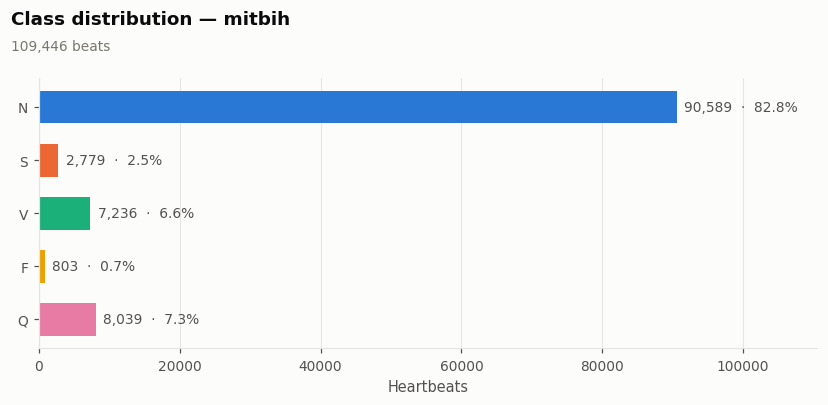

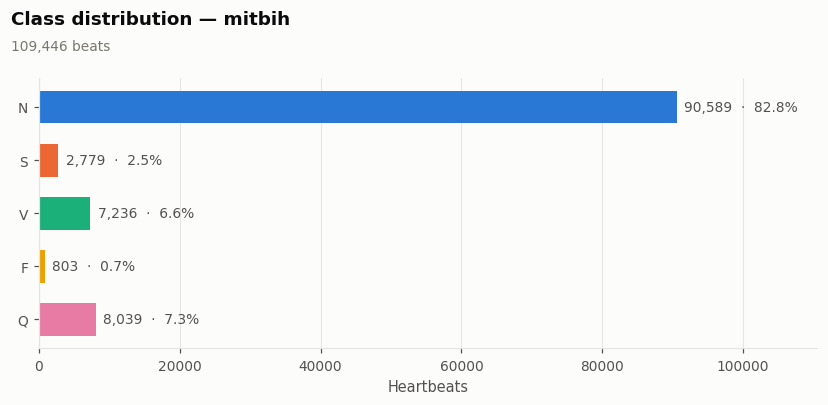

In [6]:
viz.plot_class_distribution(distribution, SOURCE, ORDER)

**Finding.** The collection is severely imbalanced: normal beats (`N`) hold 82.8%
of the data while fusion beats (`F`) hold 0.73% — a **113:1 ratio**. Accuracy is
therefore a useless metric here; a model that answers "N" to everything already
scores 82.8%. Macro-averaged F1 and the per-class recall of `S` and `F` are what
will actually distinguish models.

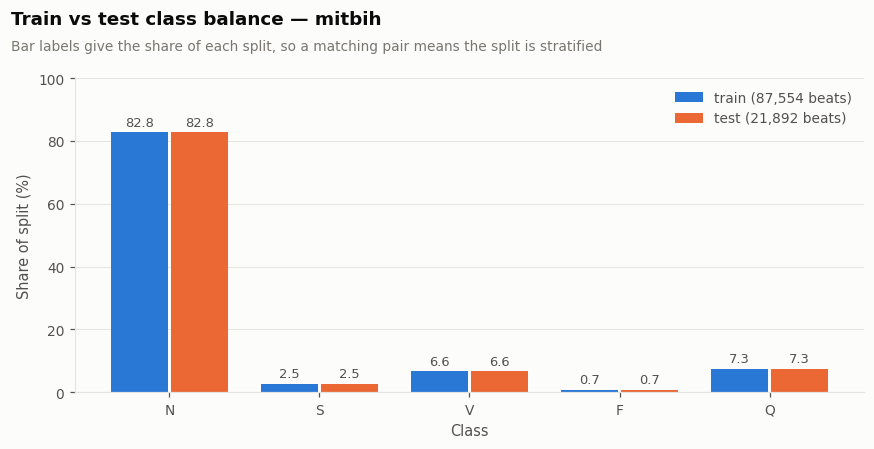

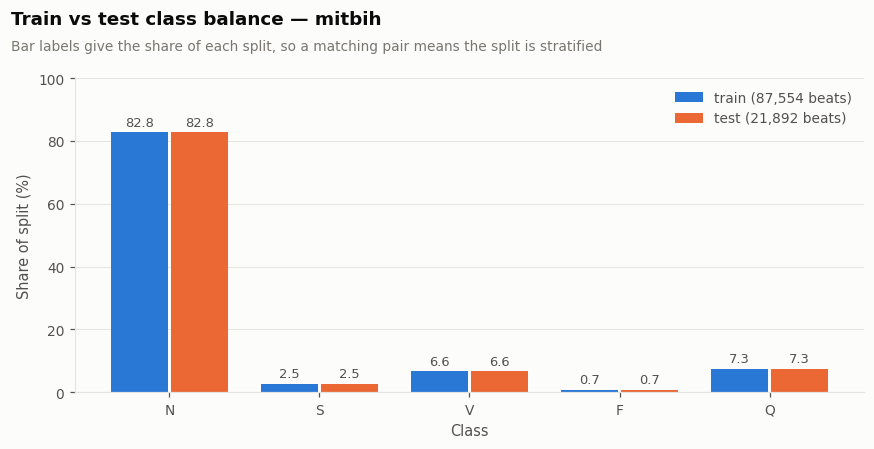

In [7]:
viz.plot_split_comparison(distribution, SOURCE, ORDER)

**Finding.** The published split is stratified: every class share matches between
train and test to within 0.02 points (`N` 82.77% vs 82.76%, `F` 0.732% vs 0.740%).
The test split can be used as published, and any validation set carved out of the
training data should be stratified the same way to stay comparable.

## 2 · Data quality

In [8]:
eda.quality_report(beats)

,check,n_beats,pct
0,rows_total,109446,100.0000
1,null_signal,0,0.0000
2,wrong_length,0,0.0000
3,null_label,0,0.0000
4,contains_null_sample,0,0.0000
5,contains_nan_sample,0,0.0000
6,below_zero,0,0.0000
7,above_one,0,0.0000
8,all_zero_beat,0,0.0000
9,max_not_one,225,0.2056


**Finding.** No nulls, no NaNs, no wrong-length rows and no amplitude outside
`[0, 1]` — the published preprocessing is intact, and there is nothing to clean.

Two small anomalies are worth recording, though. Each beat was min-max normalised,
so its maximum should be exactly 1.0 and its minimum exactly 0.0. **225 beats
(0.21%) peak below 1.0** — some as low as 0.61 — and **83 beats (0.08%) never
reach 0.0**. Both are concentrated in class `S`: 179 of the 225 flat-peaked beats
are supraventricular, i.e. 6.4% of that class against 0.04% of class `N`. The
pattern is consistent with the segmentation window clipping the R peak of beats
that arrive early — which is precisely what makes a beat supraventricular. It is a
handful of rows, not a defect to fix, but it is a leak: an amplitude-based feature
could pick up a segmentation artefact instead of physiology.

In [9]:
eda.duplicate_report(beats, by=("source",))

,source,n_beats,n_unique_waveforms,n_duplicated_beats,n_waveforms_with_conflicting_labels,n_waveforms_in_both_splits,pct_duplicated
0,mitbih,109446,109446,0,0,0,0.0


**Finding.** 109,446 beats, 109,446 distinct waveforms — **not a single exact
duplicate**, no waveform carrying two different labels, and no beat shared between
the train and test splits. There is no leakage to remove.

## 3 · Morphology

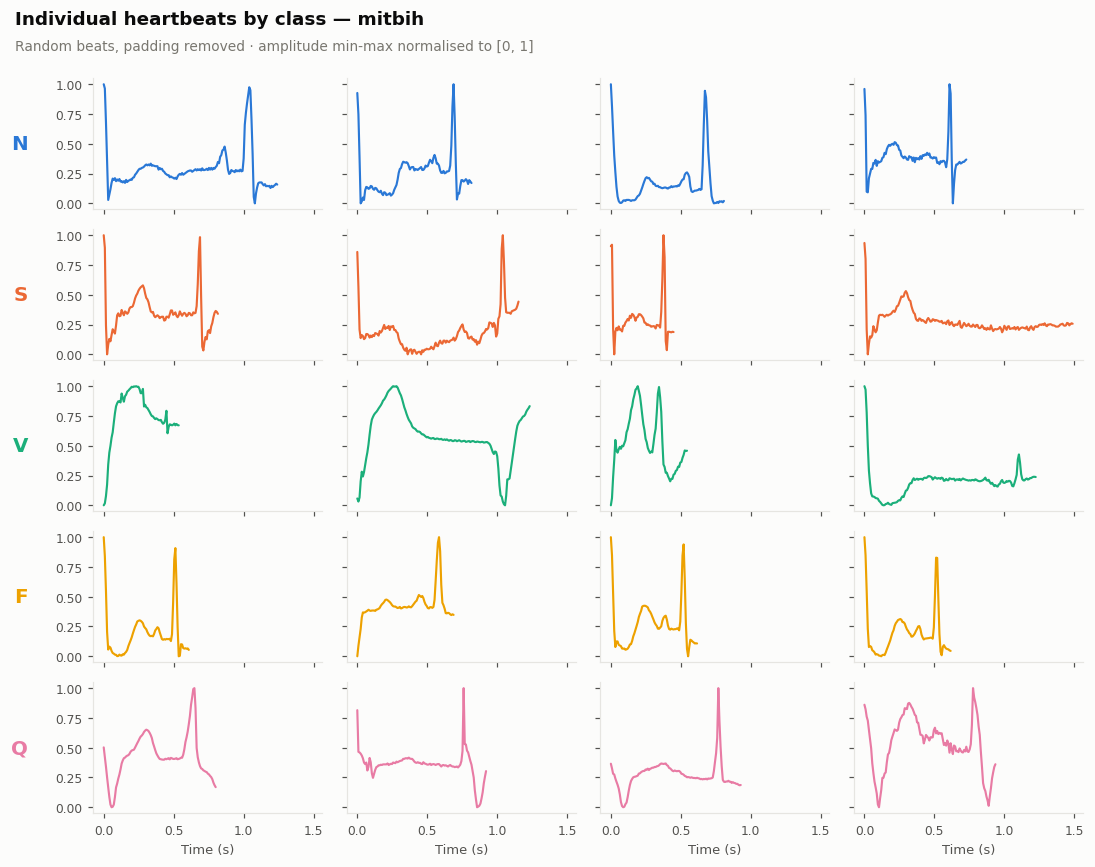

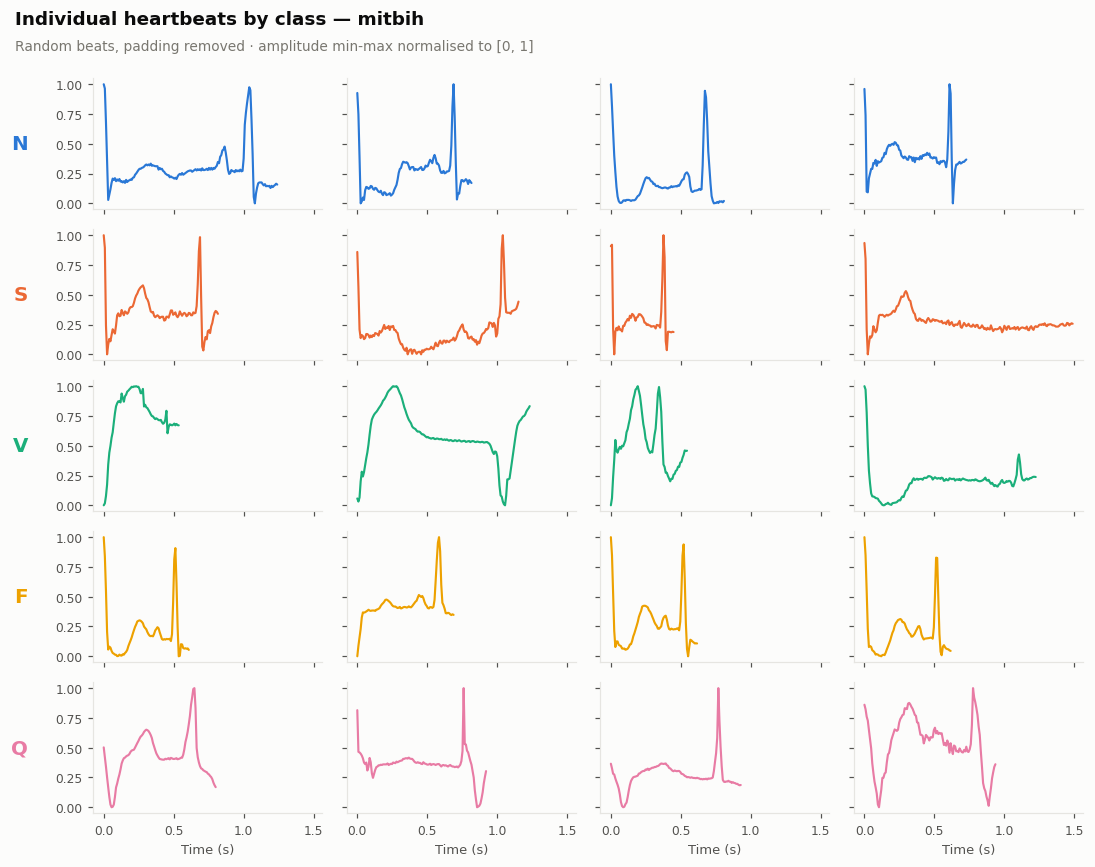

In [10]:
samples = eda.sample_beats(beats, n_per_group=cfg.plot_sample_per_class, seed=cfg.seed)
viz.plot_sample_beats(samples, SOURCE, ORDER, n_per_class=4)

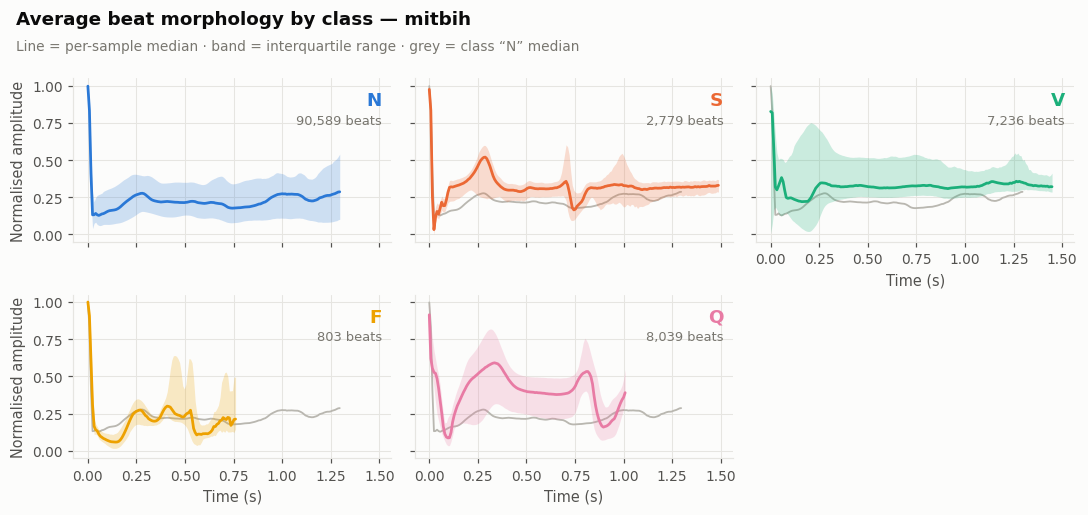

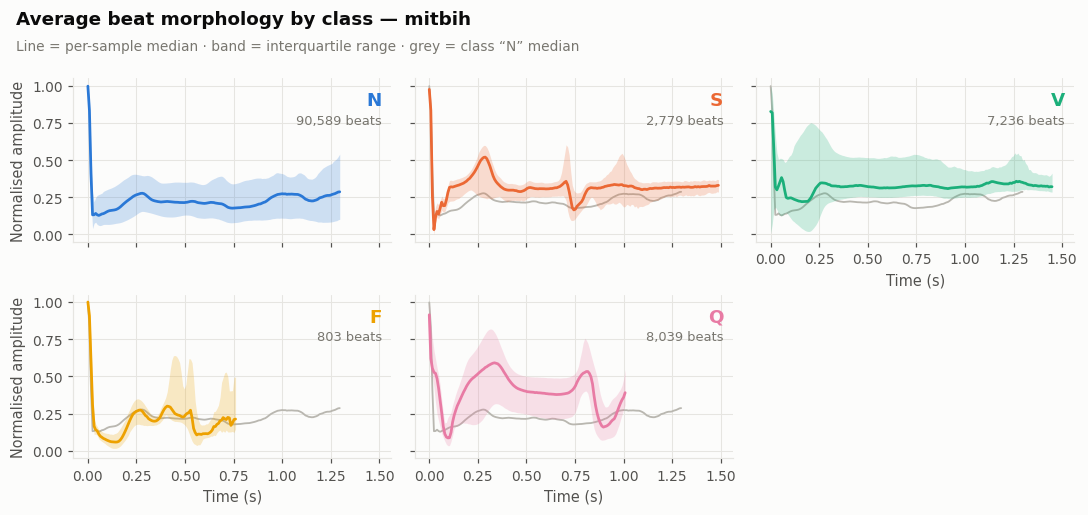

In [11]:
profile = eda.waveform_profile(beats)
viz.plot_waveform_profiles(profile, SOURCE, ORDER, n_cols=3)

**Finding.** The classes are visibly different in shape, and in ways that match the
clinical definitions: `V` (ventricular) beats are wide and slow with no sharp QRS
complex; `Q` (paced/unclassifiable) carries a large, late secondary deflection;
`F` (fusion) is markedly shorter than everything else; `S` sits closest to `N`,
which is exactly why it is the hardest class to separate. Note also that every
beat starts at amplitude 1.0 — the segmentation is R-peak aligned by construction.

## 4 · Padding and beat length

In [12]:
eda.padding_report(beats)

,source,label_name,n_beats,min_length,median_length,max_length,mean_length,mean_duration_s,pct_unpadded,pct_ambiguous_tail
0,mitbih,F,803,29,78,187,78.5,0.6277,0.12,17.31
1,mitbih,N,90589,10,106,187,110.8,0.8861,0.44,2.82
2,mitbih,Q,8039,31,120,183,118.3,0.9466,0.00,1.17
3,mitbih,S,2779,22,107,187,114.2,0.9133,11.69,0.79
4,mitbih,V,7236,14,113,187,117.9,0.9432,3.48,0.84


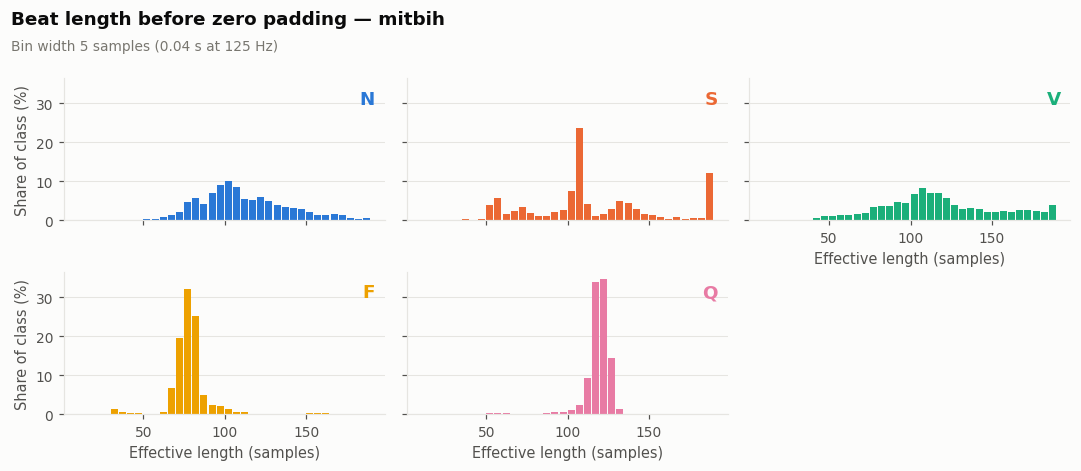

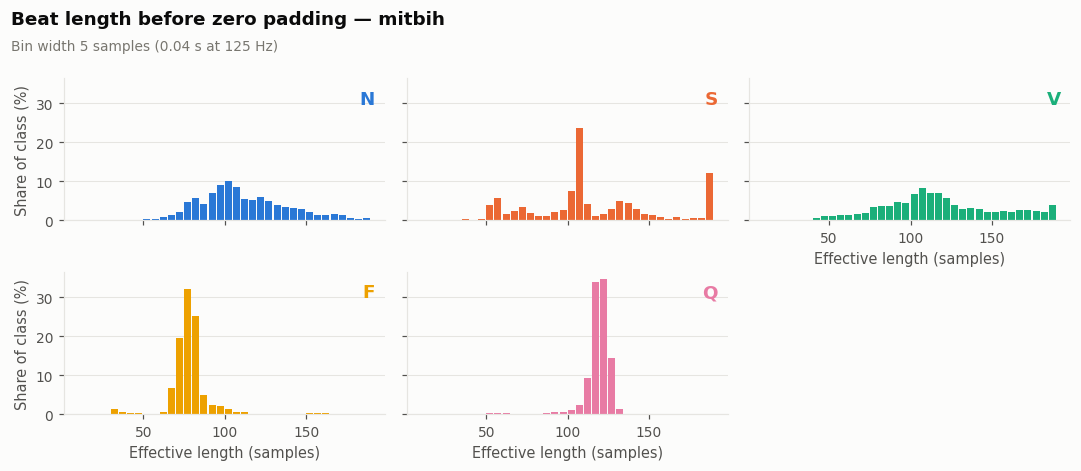

In [13]:
histogram = eda.length_histogram(beats)
viz.plot_length_distribution(histogram, SOURCE, ORDER, n_cols=3)

**Finding.** The 187-sample vector is mostly padding. Median real length ranges
from **78 samples (0.63 s) for `F`** to **120 samples (0.96 s) for `Q`**, so
between a third and a half of every input vector is zeros. Two consequences:

* amplitude statistics must be computed over the unpadded prefix, otherwise the
  padding drags every mean toward zero and short classes look artificially flat —
  which is what `ecg.features` does;
* effective length is itself informative (`F` is a full 0.3 s shorter than `Q`),
  so it is kept as a model feature.

The length histograms also show discrete spikes — 24% of class `S` shares a single
5-sample bin, and 11.7% of `S` is not padded at all — a fingerprint of the fixed
cropping window rather than of physiology.

## 5 · Per-beat descriptors

In [14]:
summary = eda.feature_summary(beats)
summary[summary["feature"].isin(["signal_length", "amp_mean", "amp_std", "energy", "peak_index", "mean_abs_diff"])]

,source,label_name,feature,n,mean,std,min,q05,q25,q50,q75,q95,max
0,mitbih,F,signal_length,803,78.4583,13.7667,29.0000,67.0000,74.0000,78.0000,81.0000,95.0000,187.0000
7,mitbih,F,amp_mean,803,0.2502,0.0823,0.1024,0.1495,0.2202,0.2427,0.2654,0.3209,0.8300
8,mitbih,F,amp_std,803,0.2062,0.0310,0.0953,0.1622,0.1870,0.1999,0.2256,0.2637,0.3079
9,mitbih,F,energy,803,9.0676,8.6008,1.8577,4.1811,6.9225,8.0255,9.0669,12.5203,118.6388
11,mitbih,F,peak_index,803,4.5866,18.0450,0.0000,0.0000,0.0000,0.0000,1.0000,34.0000,170.0000
13,mitbih,F,mean_abs_diff,803,0.0408,0.0065,0.0169,0.0321,0.0373,0.0408,0.0443,0.0492,0.1015
15,mitbih,N,signal_length,90589,110.7595,27.1741,10.0000,73.0000,93.0000,106.0000,127.0000,163.0000,187.0000
22,mitbih,N,amp_mean,90589,0.2722,0.1392,0.0375,0.1150,0.1615,0.2446,0.3438,0.5402,0.9041
23,mitbih,N,amp_std,90589,0.1702,0.0285,0.0740,0.1226,0.1509,0.1692,0.1899,0.2146,0.4577
24,mitbih,N,energy,90589,13.7220,13.4576,1.1588,4.2551,6.3827,9.1777,15.7866,37.3659,103.6235


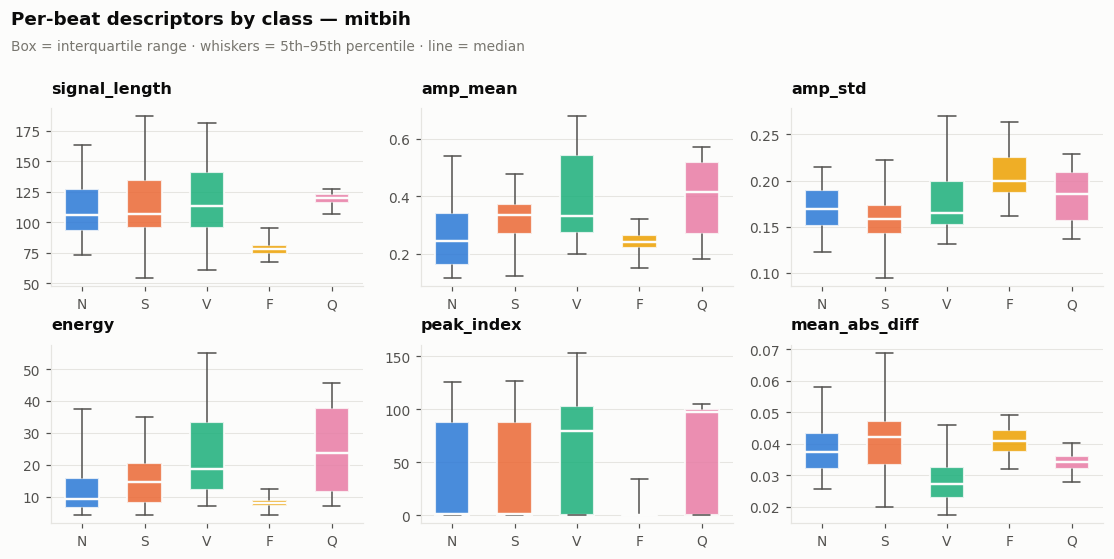

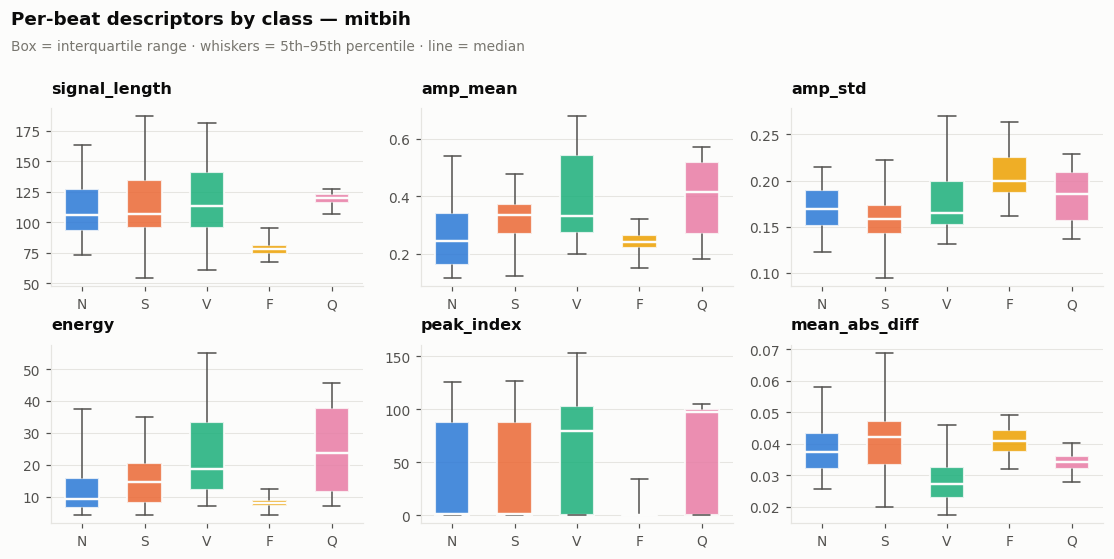

In [15]:
viz.plot_feature_boxes(
    summary,
    SOURCE,
    ["signal_length", "amp_mean", "amp_std", "energy", "peak_index", "mean_abs_diff"],
    ORDER,
)

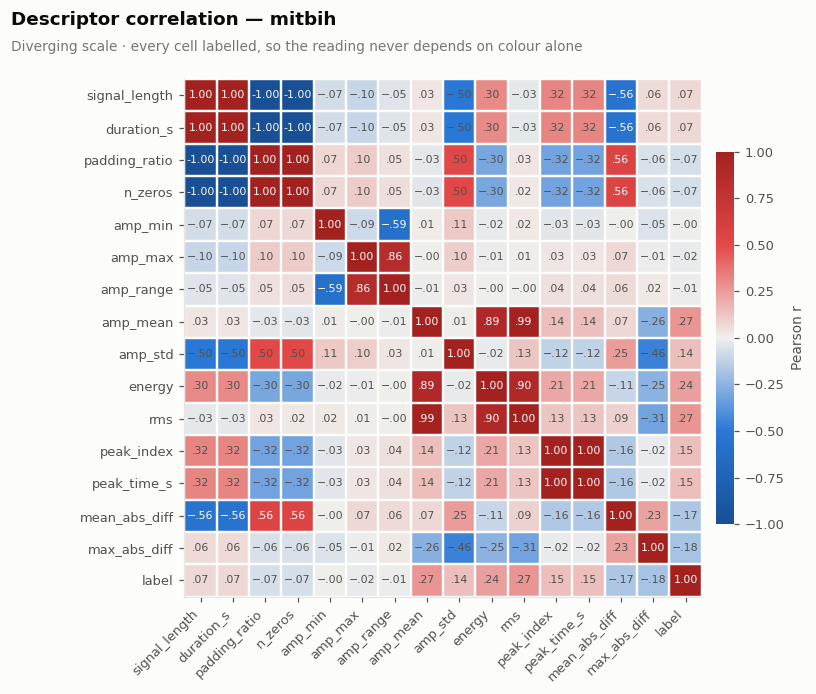

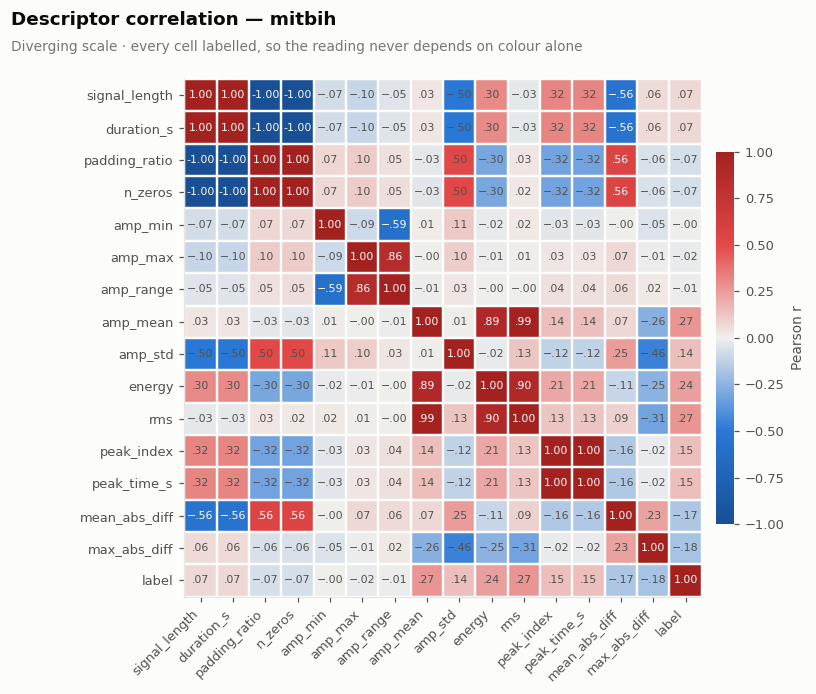

In [16]:
correlation = eda.feature_correlation(beats)
viz.plot_correlation_heatmap(correlation, title="Descriptor correlation — mitbih")

In [17]:
correlation["label"].sort_values(key=abs, ascending=False).head(8).to_frame("r_with_label")

,r_with_label
label,1.000
rms,0.272
amp_mean,0.268
energy,0.241
max_abs_diff,-0.183
mean_abs_diff,-0.166
peak_index,0.147
peak_time_s,0.147


**Finding — redundancy.** Several descriptors are the same measurement wearing
different units. `duration_s`, `padding_ratio` and `n_zeros` are perfectly
collinear with `signal_length` (|r| = 1.00); `rms` tracks `amp_mean` at r = 0.99
and `energy` at 0.89; `amp_max` is constant at 1.0 for 99.8% of beats and
`amp_range` is just `1 − amp_min`. Keeping all of them would triple-count one
signal.

**Finding — separability.** No single descriptor separates the five classes: the
strongest linear relationship with the label is r = 0.27 (`rms`). The boxes tell
the same story — the interquartile ranges overlap heavily for every descriptor.
Whatever separates these classes lives in the *shape* of the waveform, not in its
scalar summaries. That is the empirical case for feeding a model the full
187-sample vector and treating the descriptors as a small side channel.

In [18]:
print("all descriptors    :", FEATURE_COLUMNS)
print()
print("kept for modelling :", MODEL_FEATURE_COLUMNS)

all descriptors    : ['signal_length', 'duration_s', 'padding_ratio', 'n_zeros', 'amp_min', 'amp_max', 'amp_range', 'amp_mean', 'amp_std', 'energy', 'rms', 'peak_index', 'peak_time_s', 'mean_abs_diff', 'max_abs_diff']

kept for modelling : ['signal_length', 'amp_min', 'amp_mean', 'amp_std', 'peak_index', 'mean_abs_diff', 'max_abs_diff']


## Takeaways for preprocessing

| Observation | Consequence for notebook 04 |
|---|---|
| 113:1 class imbalance | Class weights by default; resampling offered but confined to the training split. Report macro-F1, never accuracy. |
| Published split already stratified | Keep the test split as published; carve validation out of train, stratified. |
| No nulls, NaNs, duplicates or leakage | No cleaning stage needed. |
| 33–50% of each vector is padding | Descriptors computed over the unpadded prefix; `signal_length` kept as a feature. |
| Descriptors heavily collinear, weakly linked to the label | Prune to 7 descriptors; the 187-sample waveform stays the primary input. |
| 225 beats with a clipped peak, mostly class `S` | Recorded as a known artefact; amplitude features to be read with that in mind. |

In [19]:
beats.unpersist()
spark.stop()